# 3D Print Failure Detection - YOLOv26 Training

Train a custom YOLOv26 model to detect 3D print failures (spaghetti, stringing, zits) using a dataset from Roboflow.

This notebook can run on:
- **Google Colab** (free GPU)
- **Jupyter Lab / Notebook** (local GPU)

## Steps
1. Install dependencies
2. Download dataset from Roboflow
3. Train YOLOv26 model
4. Evaluate and test
5. Export trained weights

## 1. Install Dependencies

In [ ]:
# %pip install ultralytics roboflow -q

In [1]:
# Verify GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):,.2f} GB")
else:
    print("No GPU detected. Training will use CPU (much slower).")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.00 GB


## 2. Download Dataset from Roboflow

Using the **3D Print Failure Detection** dataset by max.
- Classes: spaghetti, stringing, warping
- Format: YOLOv26

Get your API key from [Roboflow Settings](https://app.roboflow.com/settings/api).

In [ ]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="xxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
# project = rf.workspace("3d-printing-failure").project("3d-printing-failure")
# version = project.version(1)
# dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 3D-printing-failure-1 in yolo26:: 100%|██████████| 17718/17718 [00:09<00:00, 1933.96it/s]


In [2]:
# Inspect dataset structure
import os

dataset_location =  "3d-printing-failure-1"

for root, dirs, files in os.walk(dataset_location):
    level = root.replace(dataset_location, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = "  " * (level + 1)
        for file in files[:5]:
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

3d-printing-failure-1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test/
    images/
    labels/
  train/
    labels.cache
    images/
    labels/
  valid/
    labels.cache
    images/
    labels/


In [3]:
# Read and display data.yaml
data_yaml_path = os.path.join(dataset_location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 3
names: ['spaghetti', 'stringing', 'zits']

roboflow:
  workspace: 3d-printing-failure
  project: 3d-printing-failure
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/3d-printing-failure/3d-printing-failure/dataset/1


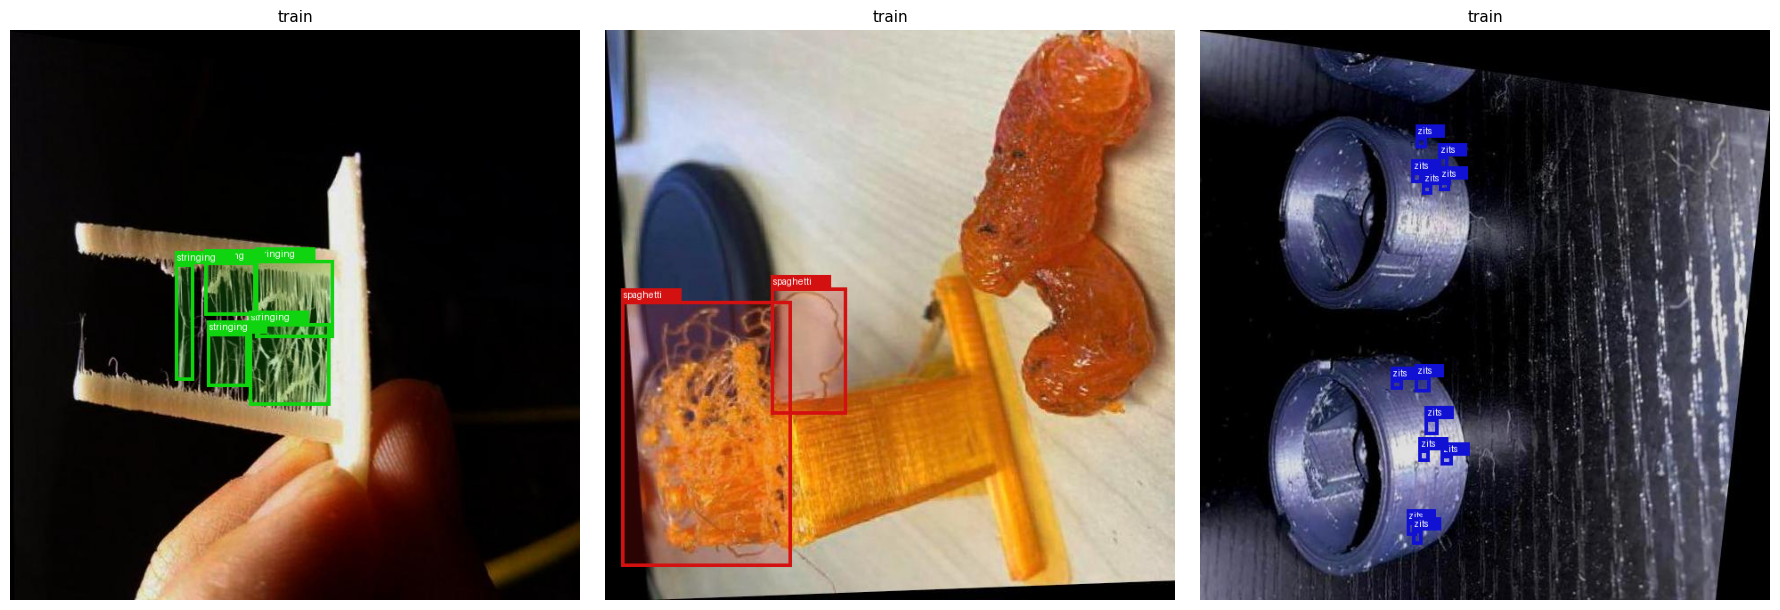

In [4]:
## Display some images
from img_display import show_samples

show_samples("3D-printing-failure-1/train", n=3)


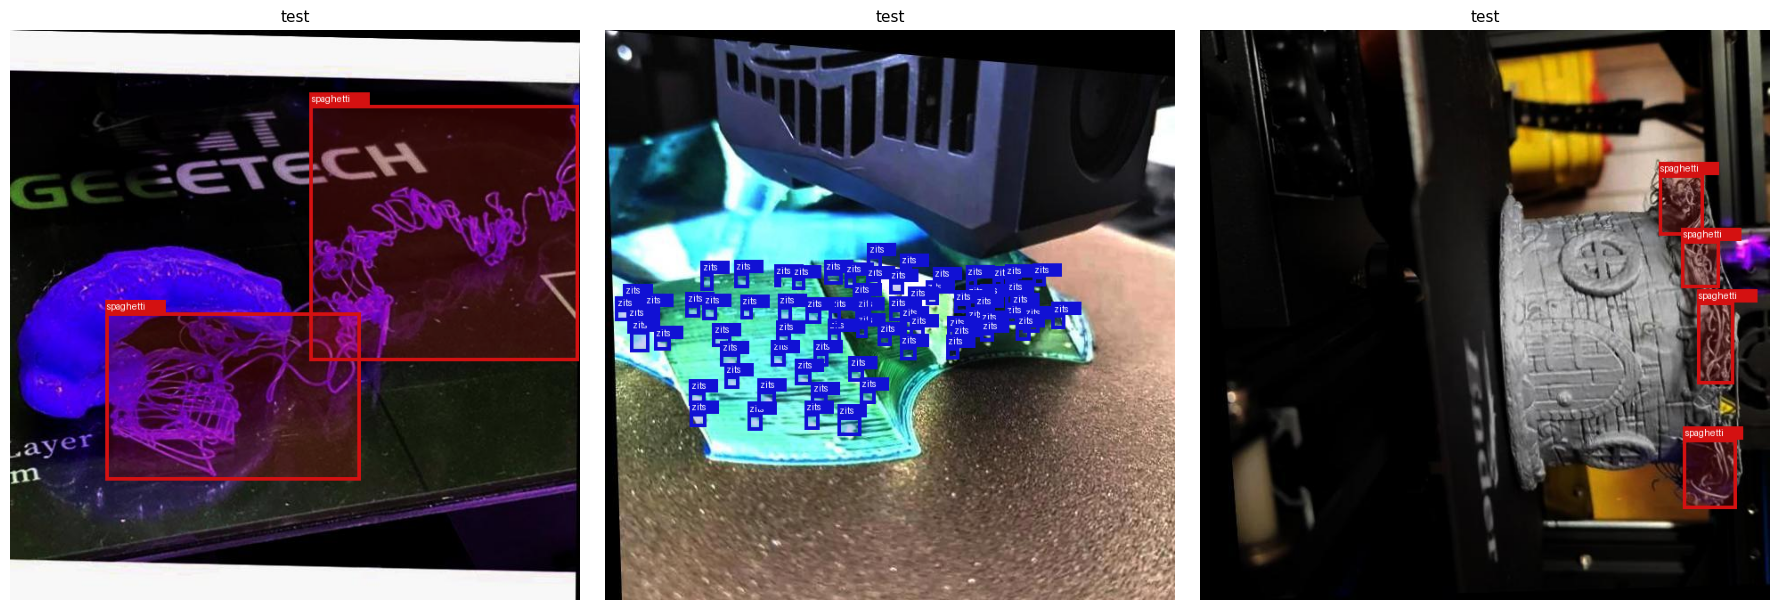

In [5]:
show_samples("3D-printing-failure-1/test", n=3)

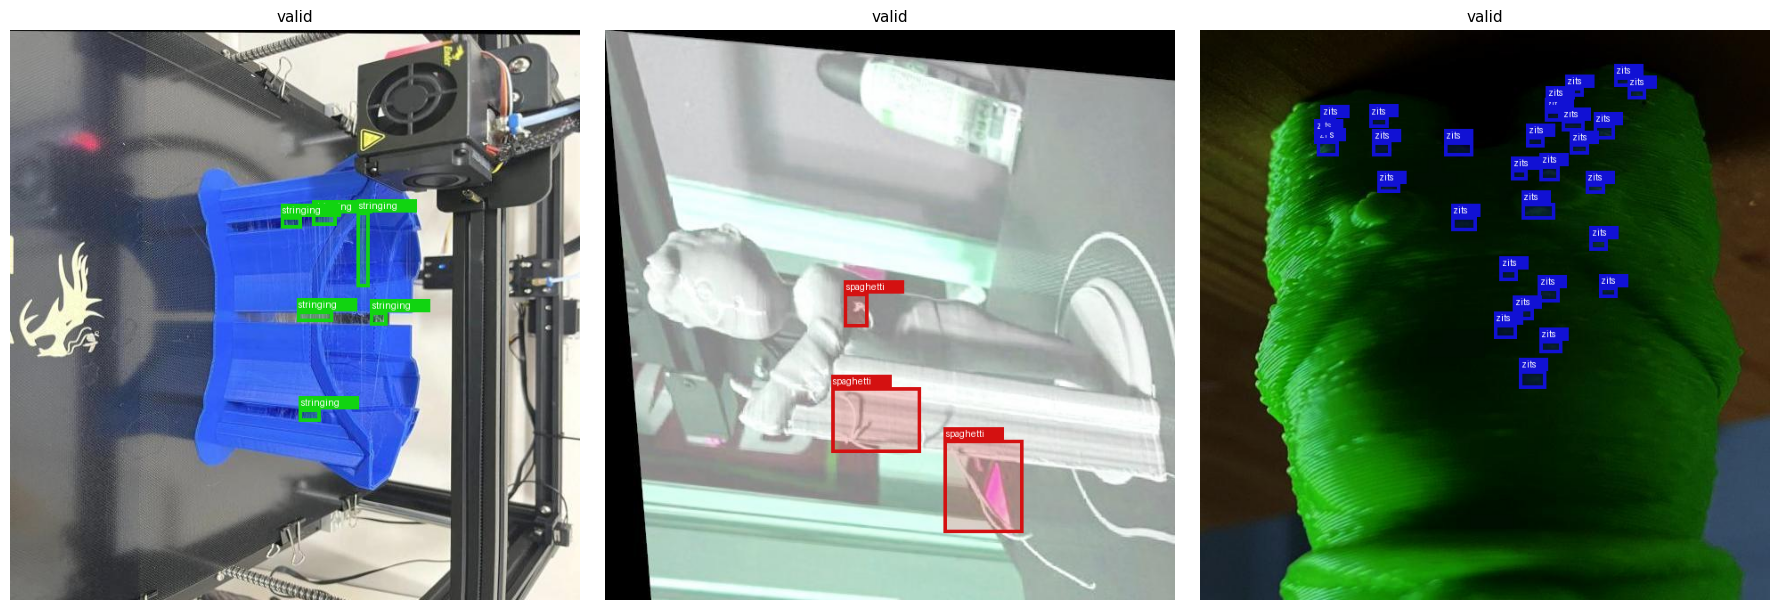

In [6]:
show_samples("3D-printing-failure-1/valid", n=3)

## ⚠️ Something is Wrong
Let's analyse why wrong results. mAP50 not increasing beyond 20%.

✅ Checklists:
 - `path in `data.yaml` with respect to project root
 - Labels exist for all?
 - Dataset imbalance
 - YOLO label format + Normalised?

### 1. Verify `data.yaml` file resolve correctly

In [7]:
import yaml, os, glob

with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

for split in ["train", "val", "test"]:
    img_dir = os.path.normpath(os.path.join(dataset_location, cfg[split]))
    imgs = glob.glob(os.path.join(img_dir, "*.*"))
    print(f"{split}: {len(imgs)} images  →  {img_dir}")
    assert len(imgs) > 0, f"⚠️ NO IMAGES FOUND for {split}!"


train: 6159 images  →  3d-printing-failure-1\train\images
val: 1346 images  →  3d-printing-failure-1\valid\images
test: 1348 images  →  3d-printing-failure-1\test\images


### 2. 🐞Debug: print what `data.yaml` says vs what actually exists


In [8]:
with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

print(f"CWD:              {os.getcwd()}")
print(f"dataset_location: {dataset_location}")
print(f"data.yaml paths:")
for split in ["train", "val", "test"]:
    raw = cfg[split]
    resolved = os.path.normpath(os.path.join(dataset_location, raw))
    exists = os.path.isdir(resolved)
    print(f"  {split}: '{raw}'  →  {resolved}  →  exists={exists}")

# Also show what folders DO exist in the dataset
print(f"\nActual contents of {dataset_location}:")
for item in os.listdir(dataset_location):
    full = os.path.join(dataset_location, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ ({count} items)")
    else:
        print(f"  📄 {item}")


CWD:              c:\Users\User\Desktop\Me\3dPrint\src
dataset_location: 3d-printing-failure-1
data.yaml paths:
  train: 'train/images'  →  3d-printing-failure-1\train\images  →  exists=True
  val: 'valid/images'  →  3d-printing-failure-1\valid\images  →  exists=True
  test: 'test/images'  →  3d-printing-failure-1\test\images  →  exists=True

Actual contents of 3d-printing-failure-1:
  📄 data.yaml
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 test/ (2 items)
  📁 train/ (3 items)
  📁 valid/ (3 items)


I see, wrong relative path of Train Test Valid samples in `config.yaml` file. Corrected now.

In [9]:
with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

print(f"CWD:              {os.getcwd()}")
print(f"dataset_location: {dataset_location}")
print(f"data.yaml paths:")
for split in ["train", "val", "test"]:
    raw = cfg[split]
    resolved = os.path.normpath(os.path.join(dataset_location, raw))
    exists = os.path.isdir(resolved)
    print(f"  {split}: '{raw}'  →  {resolved}  →  exists={exists}")

# Also show what folders DO exist in the dataset
print(f"\nActual contents of {dataset_location}:")
for item in os.listdir(dataset_location):
    full = os.path.join(dataset_location, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ ({count} items)")
    else:
        print(f"  📄 {item}")


CWD:              c:\Users\User\Desktop\Me\3dPrint\src
dataset_location: 3d-printing-failure-1
data.yaml paths:
  train: 'train/images'  →  3d-printing-failure-1\train\images  →  exists=True
  val: 'valid/images'  →  3d-printing-failure-1\valid\images  →  exists=True
  test: 'test/images'  →  3d-printing-failure-1\test\images  →  exists=True

Actual contents of 3d-printing-failure-1:
  📄 data.yaml
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 test/ (2 items)
  📁 train/ (3 items)
  📁 valid/ (3 items)


### 3. Check Labels Exists and are not Empty

In [10]:
# Do label files actually exist alongside images?
train_img_dir = os.path.normpath(os.path.join(dataset_location, cfg["train"]))
train_lbl_dir = train_img_dir.replace("images", "labels")

imgs = glob.glob(os.path.join(train_img_dir, "*.*"))
empty, missing = 0, 0
for img in imgs:
    lbl = os.path.join(train_lbl_dir, os.path.splitext(os.path.basename(img))[0] + ".txt")
    if not os.path.exists(lbl):
        missing += 1
    elif os.path.getsize(lbl) == 0:
        empty += 1

print(f"Total images: {len(imgs)}")
print(f"Missing labels: {missing}")
print(f"Empty labels (background): {empty}")
print(f"Labeled images: {len(imgs) - missing - empty}")


Total images: 6159
Missing labels: 0
Empty labels (background): 1
Labeled images: 6158


### 4. Validate label format ( Must be Normalized)

In [11]:
import random

# Pick a random label and inspect
lbls = glob.glob(os.path.join(train_lbl_dir, "*.txt"))
sample = random.choice([l for l in lbls if os.path.getsize(l) > 0])
print(f"Sample: {sample}\n")
with open(sample) as f:
    for line in f:
        parts = line.strip().split()
        print(f"  class={parts[0]}  cx={parts[1]}  cy={parts[2]}  w={parts[3]}  h={parts[4]}")
        # ALL values after class should be between 0.0 and 1.0
        for v in parts[1:]:
            assert 0.0 <= float(v) <= 1.0, f"⚠️ VALUE {v} OUT OF RANGE — labels may be pixel coords, not normalized!"
print("\n✅ Format looks correct")


Sample: 3d-printing-failure-1\train\labels\93ecqbhawaia1_cropped_jpg.rf.4e4784b31955662aafe6cdc4c1756517.txt

  class=2  cx=0.221875  cy=0.4984375  w=0.01875  h=0.025
  class=2  cx=0.2734375  cy=0.49140625  w=0.01875  h=0.01875
  class=2  cx=0.3203125  cy=0.5296875  w=0.0171875  h=0.01875
  class=2  cx=0.371875  cy=0.51953125  w=0.0125  h=0.015625
  class=2  cx=0.36171875  cy=0.490625  w=0.0140625  h=0.01875
  class=2  cx=0.41640625  cy=0.49609375  w=0.0171875  h=0.021875
  class=2  cx=0.46796875  cy=0.51171875  w=0.015625  h=0.01875
  class=2  cx=0.54375  cy=0.53125  w=0.0140625  h=0.0140625
  class=2  cx=0.58828125  cy=0.4921875  w=0.0171875  h=0.0203125
  class=2  cx=0.16796875  cy=0.54921875  w=0.0140625  h=0.01875
  class=2  cx=0.2140625  cy=0.57890625  w=0.0125  h=0.0125
  class=2  cx=0.2671875  cy=0.5734375  w=0.015625  h=0.0171875
  class=2  cx=0.325  cy=0.4546875  w=0.0140625  h=0.0125
  class=2  cx=0.37578125  cy=0.4453125  w=0.0203125  h=0.01875
  class=2  cx=0.5125  cy=0.49

### 5. Check Class Distribution (Imbalance?)

In [12]:
from collections import Counter

class_counts = Counter()
for lbl in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(lbl) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            class_counts[cls] += 1

print("Class distribution:")
for cls_id, count in sorted(class_counts.items()):
    print(f"  {cfg['names'][cls_id]:>12s} (class {cls_id}): {count} instances")


Class distribution:
     spaghetti (class 0): 9794 instances
     stringing (class 1): 2380 instances
          zits (class 2): 31336 instances


Huge imbalance observed. 

Measures:
 - cosine LR schedule (gentler decay)
 - augment = True (mosaic + mixup)


## Retrain Now

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv26 nano model
model = YOLO("yolo26n.pt")

# Train on our dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=8,            # Lower to 8 if you get OOM errors
    name="print_failure_detector_v26_nano",
    cos_lr=True,        # cosine LR schedule — gentler decay
    patience=10,        # Early stopping
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=3d-printing-failure-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale

## 5. Evaluate Model


In [ ]:
from ultralytics import YOLO

# Load the best weights
best_model = YOLO("runs/detect/print_failure_detector_v26_nano4_map_0.6/weights/best.pt")

# Run validation
metrics = best_model.val()

print(f"\nmAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")

Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.2 ms, read: 49.628.4 MB/s, size: 33.4 KB)
val: Scanning C:\Users\User\Desktop\Me\3dPrint\src\3d-print-failure-detection-1\valid\labels.cache... 1524 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1524/1524 581.1Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 353, len(boxes) = 3420. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 6.2it/s 15.4s0.1s
                   all       1524       3420      0.441      0.287       0.26      0.133
             spaghetti        635       1354       0.52      0.493

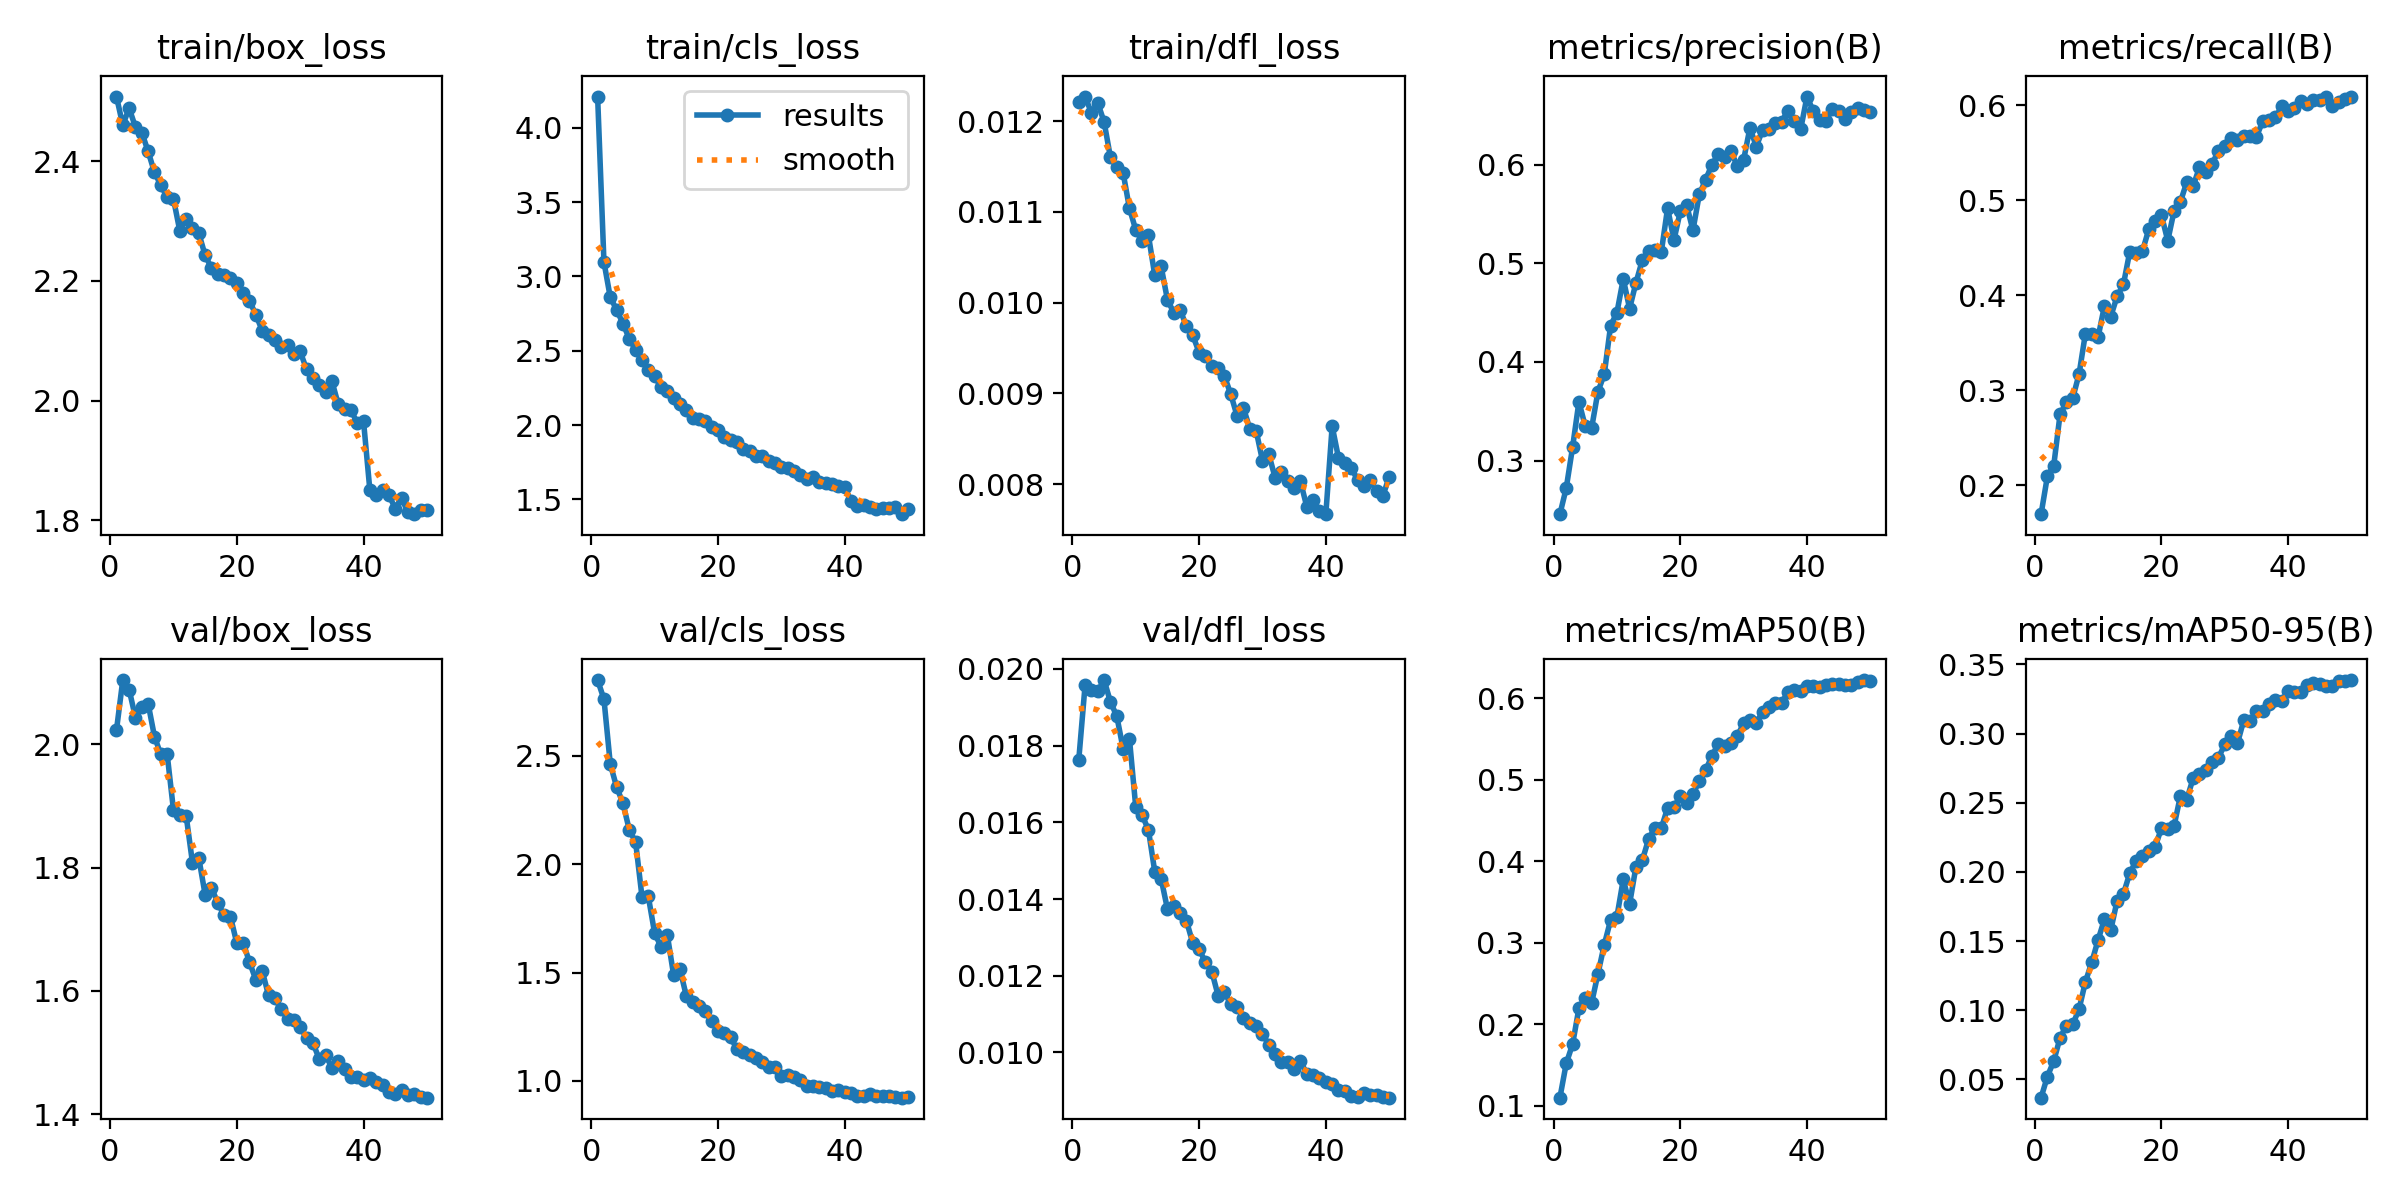

In [17]:
# Display training results
from IPython.display import Image, display

# Training curves
results_img = "runs/detect/print_failure_detector_v26_nano4_map_0.6/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img, width=800))
else:
    print(f"Results image not found at {results_img}")

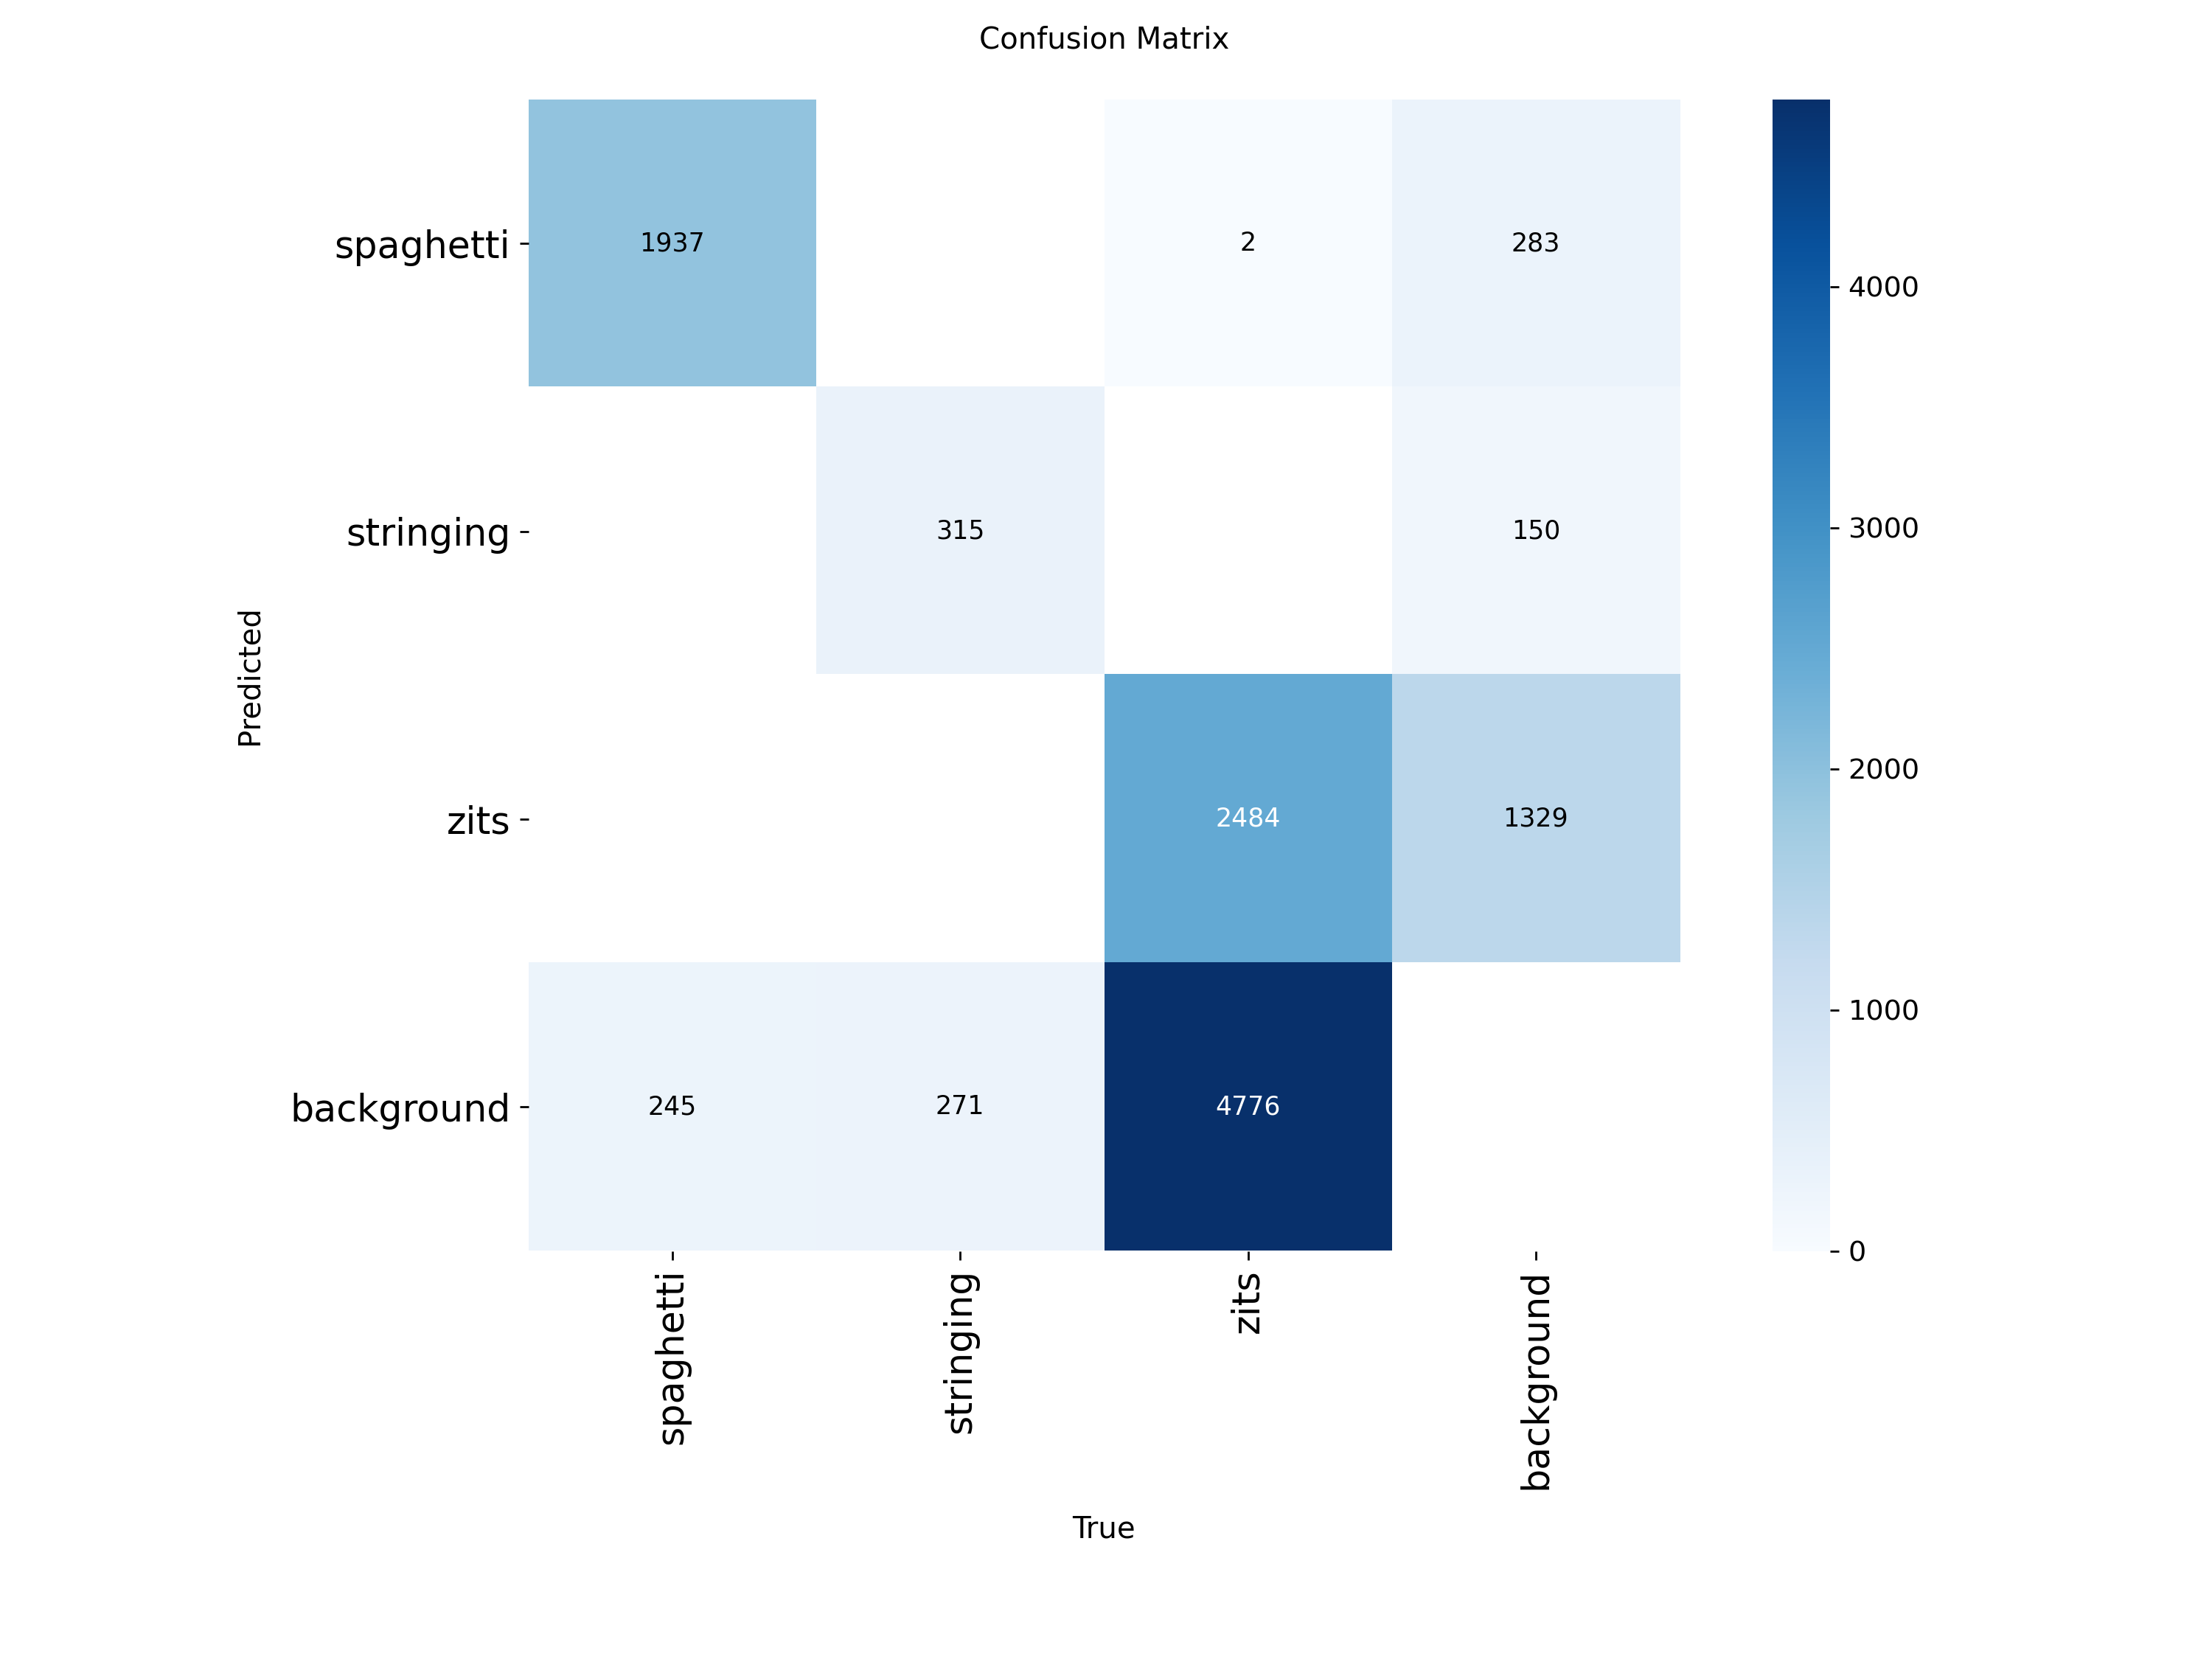

In [18]:
# Confusion matrix
cm_img = "runs/detect/print_failure_detector_v26_nano4_map_0.6/confusion_matrix.png"
if os.path.exists(cm_img):
    display(Image(filename=cm_img, width=600))
else:
    print(f"Confusion matrix not found at {cm_img}")

`Spaghetti` detection is strong but rest needs improvement. Let's retrain for longer with augmentation and see how it improves. We will continue from current checkpoint.

In [19]:
from ultralytics import YOLO

# Resume from best checkpoint
model = YOLO(r"runs\detect\print_failure_detector_v26_nano4_map_0.6\weights\best.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=800,           # 640→800: bigger input helps detect tiny zits ( do it if you have vRAM)
    batch=16,
    name="print_failure_detector_v26_nano5",
    cos_lr=True,
    patience=20,
    save=True,
    plots=True,

    # --- Loss weights ---
    box=8.5,             # Boost box loss (default 7.5) → tighter localization on small zits
    cls=1.0,             # Boost cls loss (default 0.5) → help distinguish zits vs stringing

    # --- Augmentation ---
    mosaic=1.0,          # Packs 4 images → more small objects per batch
    close_mosaic=15,     # Keep mosaic on longer (default 10) → more exposure to dense scenes
    mixup=0.15,          # Image blending for diversity
    copy_paste=0.15,     # Copy-paste instances → helps stringing (rarest class)
    scale=0.7,           # Wider zoom → better multi-scale, especially small zits
    degrees=10.0,        # Rotation
    shear=2.0,           # Shear
    flipud=0.1,          # Vertical flip
    hsv_h=0.02,
    hsv_s=0.75,
    hsv_v=0.5,
    erasing=0.3,
)


New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=3d-printing-failure-1\data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=runs\detect\print_failure_detector_v26_nano4_m

In [ ]:
from ultralytics import YOLO

# Resume from best checkpoint
model = YOLO("yolo26n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=800,           # 640→800: bigger input helps detect tiny zits ( do it if you have vRAM)
    batch=16,
    name="print_failure_detector_v26_nano6",
    cos_lr=True,
    patience=20,
    save=True,
    plots=True,

    # --- Loss weights
    box=8.5,             # Boost box loss (default 7.5) → tighter localization on small zits
    cls=1.0,             # Boost cls loss (default 0.5) → help distinguish zits vs stringing

    # --- Augmentation
    mosaic=1.0,          # Packs 4 images → more small objects per batch
    close_mosaic=15,     # Keep mosaic on longer (default 10) → more exposure to dense scenes
    mixup=0.15,          # Image blending for diversity
    copy_paste=0.15,     # Copy-paste instances → helps stringing (rarest class)
    scale=0.7,           # Wider zoom → better multi-scale, especially small zits
    degrees=10.0,        # Rotation
    shear=2.0,           # Shear
    flipud=0.1,          # Vertical flip
    hsv_h=0.02,
    hsv_s=0.75,
    hsv_v=0.5,
    erasing=0.3,
)


## 6. Export Model

The trained weights are saved at:
```
runs/detect/print_failure_detector/weights/best.pt
```

Download this file and place it in your `PrintFailureDetection/` directory to use with `print_monitor.py`.

In [ ]:
# Export to ONNX (optional, for deployment on edge devices)
# best_model.export(format="onnx")

print("Best weights location:")
weights_path = "runs/detect/print_failure_detector/weights/best.pt"
if os.path.exists(weights_path):
    size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"  {weights_path} ({size_mb:.1f} MB)")
else:
    print(f"  Weights not found at {weights_path}")

print("\nTraining complete! Download best.pt and run:")
print("  python print_monitor.py")

---

## Quick Reference

| Metric | What it means |
|--------|---------------|
| **mAP@0.5** | Accuracy at 50% IoU threshold (main metric) |
| **mAP@0.5:0.95** | Average accuracy across IoU thresholds |
| **Recall** | What fraction of real failures are detected |
| **Precision** | What fraction of detections are correct |

**Target:** mAP@0.5 > 0.7 for usable detection. Prioritize **high recall for spaghetti** (better to false alarm than miss a real failure).